# SCOS SNR Analysis
Plots SNR vs relative gate offset, grouped by **laser power level** and **metric (raw / corrected)**.

- **Gated SCOS** – connected line (one line per SCOS_Scan folder at the same power level, averaged across scans)
- **PaLS-iSCOS** – scatter points (individual measurements from ref-* folders)
- Dashed vertical line at **relative offset = 0** (TPSF peak)

In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "figure.titlesize": 18,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH = r'D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results.csv'   # <-- adjust if needed
METRICS   = ['raw', 'corrected', 'intensity']          # metrics to plot
SAVE_PATH = CSV_PATH.replace('.csv', '_plots')  # directory to save plots
# ──────────────────────────────────────────────────────────────────────────────
#create save directory if it doesn't exist
Path(SAVE_PATH).mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df)} rows')
df.head()

Loaded 405 rows


,folder,gate_offset,gate_index,relative_offset_ns,method,metric,SNR_dB,BPM,f_max_Hz
0,SCOS_Scan_1777205818-40%,40384.2,0.0,-300.0,Gated SCOS,raw,25.716731,87.090671,1.451511
1,SCOS_Scan_1777205818-40%,40384.2,0.0,-300.0,Gated SCOS,corrected,24.865003,87.090671,1.451511
2,SCOS_Scan_1777205818-40%,40384.2,0.0,-300.0,Gated SCOS,intensity,20.531195,87.090671,1.451511
3,SCOS_Scan_1777205818-40%,40484.2,1.0,-200.0,Gated SCOS,raw,24.797622,87.090671,1.451511
4,SCOS_Scan_1777205818-40%,40484.2,1.0,-200.0,Gated SCOS,corrected,25.382566,87.090671,1.451511


In [11]:
# ── PARSE POWER LEVEL FROM FOLDER NAME ───────────────────────────────────────
def extract_power(folder: str) -> str:
    """Return e.g. '40%' or '30%' (unsigned) from any folder string."""
    m = re.search(r'(\d+(?:\.\d+)?%)', str(folder))
    return m.group(1) if m else 'unknown'

df['power_level'] = df['folder'].apply(extract_power)

# Drop rows without a valid relative_offset_ns or SNR
df = df.dropna(subset=['relative_offset_ns', 'SNR_dB', 'metric', 'method'])

print('Power levels found:', sorted(df['power_level'].unique()))
print('Methods found:     ', sorted(df['method'].unique()))
print('Metrics found:     ', sorted(df['metric'].unique()))

Power levels found: ['30%', '40%']
Methods found:      ['Gated SCOS', 'PaLS-iSCOS']
Metrics found:      ['corrected', 'intensity', 'raw']


In [12]:
# ── PLOTTING HELPER ───────────────────────────────────────────────────────────

GATED_METHODS  = [m for m in df['method'].unique() if 'Gated' in m]
SINGLE_METHODS = [m for m in df['method'].unique() if 'Gated' not in m]


POWER_LEVELS = sorted(df['power_level'].unique())

# Build a colour map: one distinct colour per (method_type, power) combination
# method_type = 'gated' or 'single'
series_keys = [(mtype, p) for mtype in ['gated', 'single'] for p in POWER_LEVELS]
CMAP = plt.cm.get_cmap('tab10', len(series_keys))
SERIES_COLORS = {
    ('gated'): 'tab:blue',
    ('single'): 'tab:orange'
}

def agg_snr(group_df):
    """Return mean, std (NaN-safe) and count per relative_offset_ns."""
    return (
        group_df.groupby('relative_offset_ns')['SNR_dB']
                .agg(mean='mean', std='std', n='count')
                .reset_index()
                .sort_values('relative_offset_ns')
    )


def plot_snr_comparison(metric: str, ax: plt.Axes):
    """
    On *ax*, draw:
      - One line per power level for Gated SCOS (mean ± std error bars)
      - Scatter points per power level for PaLS-iSCOS (mean ± std error bars)
      - Each (method, power) series gets its own distinct colour
      - Vertical dashed line at offset = 0 (TPSF peak)
      - All offsets plotted (no bottom clip)
    """
    sub = df[df['metric'] == metric]

    handles, labels = [], []

    for power in POWER_LEVELS:
        gated_color  = SERIES_COLORS[('gated')]
        single_color = SERIES_COLORS[('single')]

        # --- Gated SCOS line + error bars ---
        gated = sub[sub['method'].isin(GATED_METHODS) & (sub['power_level'] == power)]
        if not gated.empty:
            g = agg_snr(gated)
            eb = ax.errorbar(
                g['relative_offset_ns'], g['mean'],
                yerr=g['std'].fillna(0),
                fmt='-s', linewidth=1.8, markersize=6,
                color=gated_color, ecolor=gated_color, elinewidth=1.2,
                capsize=4, capthick=1.2,
                label=f'Gated SCOS {power}'
            )
            handles.append(eb); labels.append(f'Gated SCOS {power}')

        # --- PaLS-iSCOS scatter + error bars ---
        single = sub[sub['method'].isin(SINGLE_METHODS) & (sub['power_level'] == power)]
        if not single.empty:
            s = agg_snr(single)
            eb = ax.errorbar(
                s['relative_offset_ns'], s['mean'],
                yerr=s['std'].fillna(0),
                fmt='o', markersize=8, linewidth=0,
                color=single_color, ecolor=single_color, elinewidth=1.2,
                capsize=4, capthick=1.2, zorder=5,
                markeredgecolor='k', markeredgewidth=0.5,
                label=f'PaLS-iSCOS {power}'
            )
            handles.append(eb); labels.append(f'PaLS-iSCOS {power}')

    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    handles.append(plt.Line2D([0],[0], color='red', linestyle='--')); labels.append('TPSF Peak')
    if metric.capitalize() == 'Intensity':
        ax.set_title(f'SNR Comparison – {metric.capitalize()}', fontsize=18, fontweight='bold')
    else:
        ax.set_title(f'SNR Comparison – {metric.capitalize()} SCOS', fontsize=18, fontweight='bold')
    ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
    ax.set_ylabel('SNR (dB)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(handles, labels, fontsize=12, loc='upper right')


print('Helper defined ✓')

Helper defined ✓


C:\Users\Shira\AppData\Local\Temp\ipykernel_37820\1640749856.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap('tab10', len(series_keys))


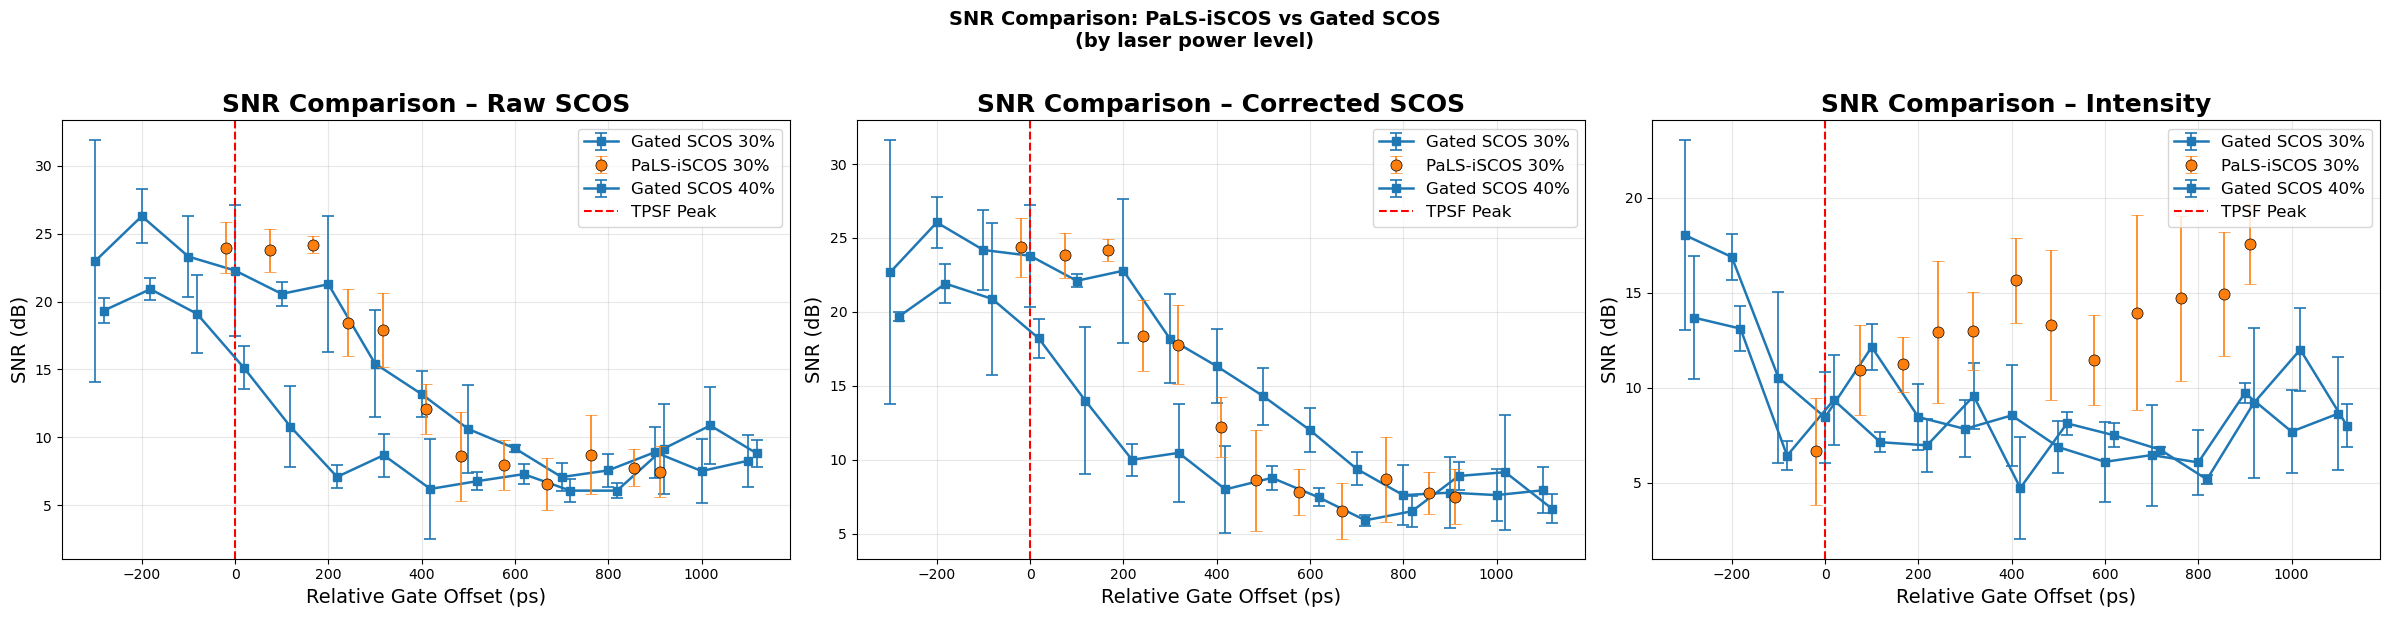

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_by_power.png


In [13]:
# ── MAIN FIGURE: Raw vs Corrected side-by-side ────────────────────────────────
fig, axes = plt.subplots(1, len(METRICS), figsize=(8 * len(METRICS), 6), sharey=False)

if len(METRICS) == 1:
    axes = [axes]

for ax, metric in zip(axes, METRICS):
    plot_snr_comparison(metric, ax)

fig.suptitle(
    'SNR Comparison: PaLS-iSCOS vs Gated SCOS\n(by laser power level)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/scos_snr_by_power.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {SAVE_PATH}/scos_snr_by_power.png')

SNR Comparison – Raw SCOS (Laser Power 30%)


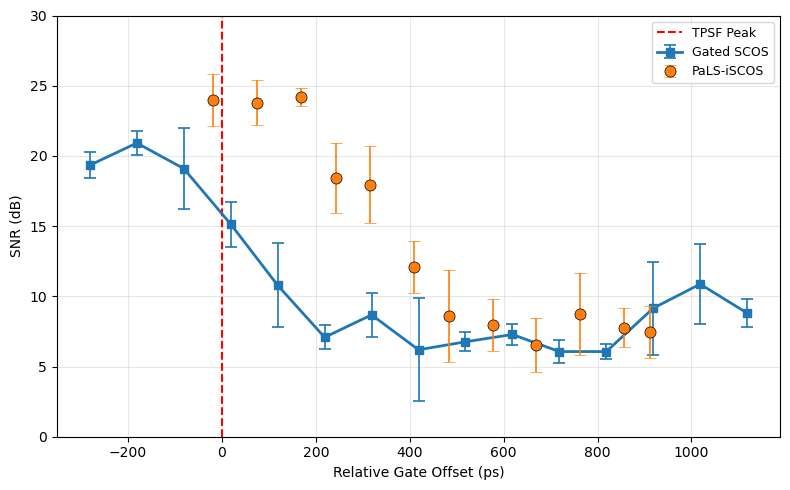

  Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_30pct_raw.png
SNR Comparison – Corrected SCOS (Laser Power 30%)


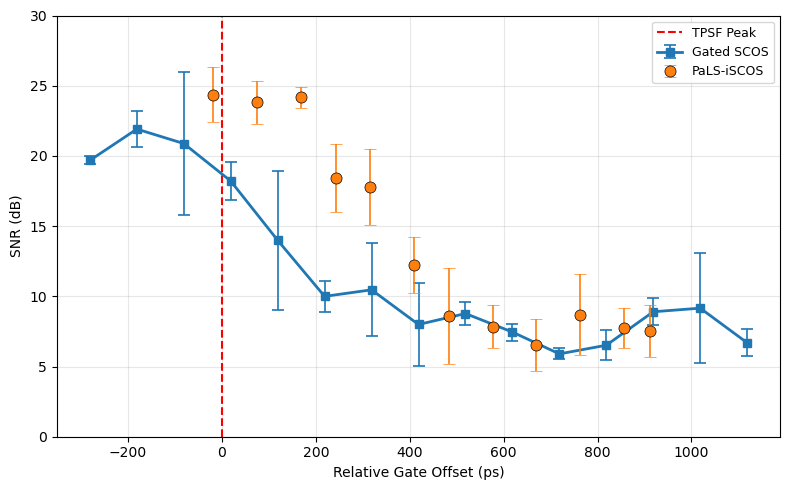

  Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_30pct_corrected.png
SNR Comparison – Intensity (Laser Power 30%)


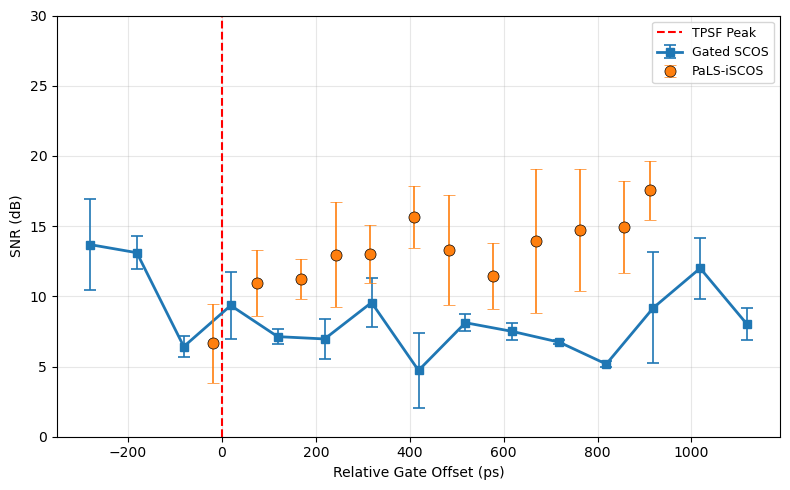

  Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_30pct_intensity.png
SNR Comparison – Raw SCOS (Laser Power 40%)


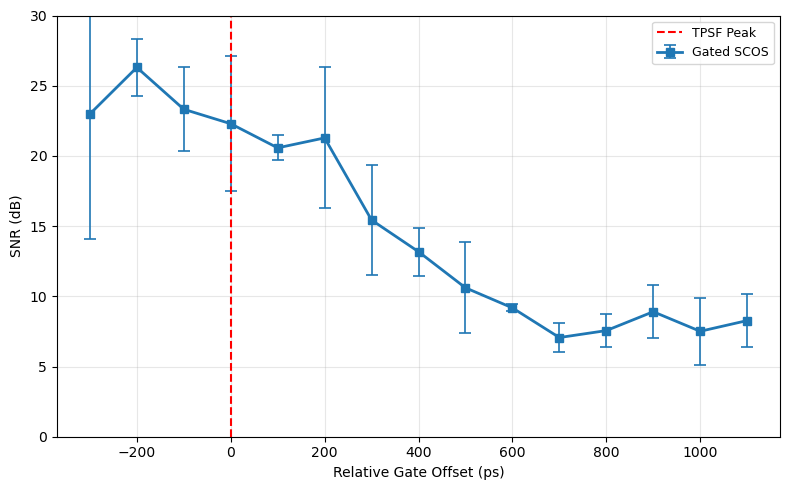

  Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_40pct_raw.png
SNR Comparison – Corrected SCOS (Laser Power 40%)


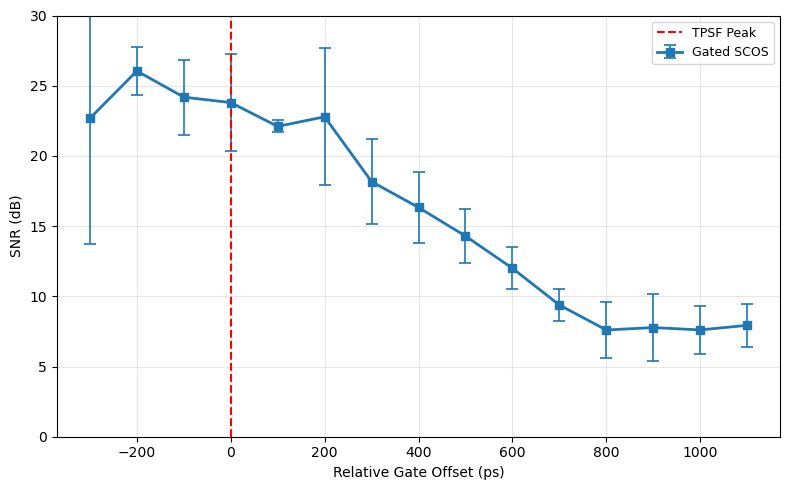

  Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_40pct_corrected.png
SNR Comparison – Intensity (Laser Power 40%)


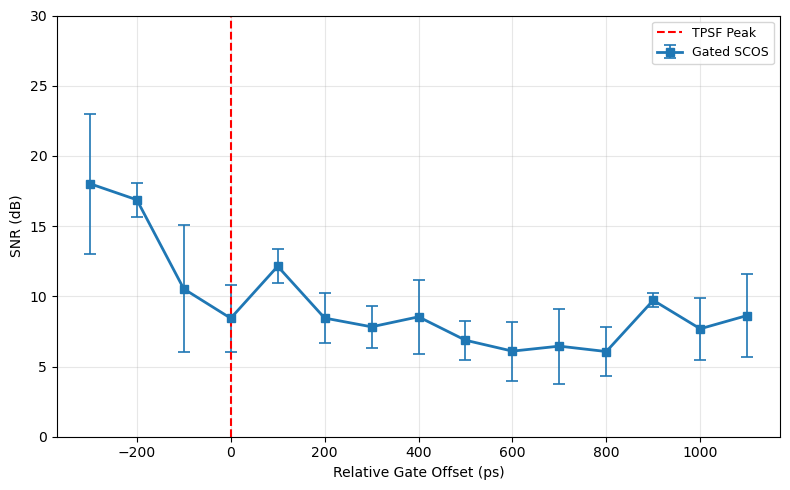

  Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_40pct_intensity.png


In [14]:
# ── OPTIONAL: One figure per metric per power level ────────
for power in POWER_LEVELS:
    sub_power = df[df['power_level'] == power]
    if sub_power.empty:
        continue

    # Loop over each metric separately to generate individual figures
    for metric in METRICS:
        sub = sub_power[sub_power['metric'] == metric]
        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 5))

        # Gated line + error bars
        gated = sub[sub['method'].isin(GATED_METHODS)]
        if not gated.empty:
            g = agg_snr(gated)
            ax.errorbar(g['relative_offset_ns'], g['mean'],
                        yerr=g['std'].fillna(0),
                        fmt='-s', color=SERIES_COLORS[('gated')],
                        ecolor=SERIES_COLORS[('gated')],
                        linewidth=2, markersize=6,
                        elinewidth=1.2, capsize=4, capthick=1.2,
                        label='Gated SCOS')

        # PaLS scatter + error bars
        single = sub[sub['method'].isin(SINGLE_METHODS)]
        if not single.empty:
            s = agg_snr(single)
            ax.errorbar(s['relative_offset_ns'], s['mean'],
                        yerr=s['std'].fillna(0),
                        fmt='o', color=SERIES_COLORS[('single')],
                        ecolor=SERIES_COLORS[('single')],
                        markersize=8, linewidth=0,
                        elinewidth=1.2, capsize=4, capthick=1.2,
                        markeredgecolor='k', markeredgewidth=0.5,
                        zorder=5, label='PaLS-iSCOS')

        # Plot formatting
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='TPSF Peak')
        
        metric_label = metric.capitalize() if metric.capitalize() == 'Intensity' else f'{metric.capitalize()} SCOS'
        print(f'SNR Comparison – {metric_label} (Laser Power {power})')
        
        ax.set_xlabel('Relative Gate Offset (ps)', fontsize=10)
        ax.set_ylabel('SNR (dB)', fontsize=10)
        ax.set_ylim(0, 30)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

        plt.tight_layout()
        
        # Include metric name in filename so separate figures don't overwrite each other
        power_clean = power.replace("%", "pct")
        metric_clean = metric.lower().replace(" ", "_")
        fname = f'{SAVE_PATH}/scos_snr_{power_clean}_{metric_clean}.png'
        
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved → {fname}')

In [15]:
# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
summary = (
    df.groupby(['power_level', 'method', 'metric'])['SNR_dB']
      .agg(['mean', 'std', 'count'])
      .rename(columns={'mean': 'SNR_mean_dB', 'std': 'SNR_std_dB', 'count': 'N'})
      .round(2)
)
print(summary.to_string())
fname=f'{SAVE_PATH}/scos_snr_summary.csv'
summary.to_csv(fname)
print(f'Saved → {fname}')

                                  SNR_mean_dB  SNR_std_dB   N
power_level method     metric                                
30%         Gated SCOS corrected        11.77        5.82  30
                       intensity         8.51        2.97  30
                       raw              10.82        5.34  30
            PaLS-iSCOS corrected        13.97        7.26  60
                       intensity        13.02        3.93  60
                       raw              13.96        7.21  60
40%         Gated SCOS corrected        16.18        7.41  45
                       intensity         9.49        4.12  45
                       raw              14.96        7.49  45
Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/scos_snr_summary.csv



Accurate BPM Counts by Relative Offset (60 < BPM < 100):
                                           Accurate_BPM_Count  Inaccurate_BPM_Count  Total_Count  Accuracy_%
method     power_level relative_offset_ns                                                                   
Gated SCOS 30%         -281.4                               3                     3            6       50.00
                       -181.4                               6                     0            6      100.00
                       -81.4                                5                     1            6       83.33
                        18.6                                5                     1            6       83.33
                        118.6                               4                     2            6       66.67
                        218.6                               4                     2            6       66.67
                        318.6                               4         

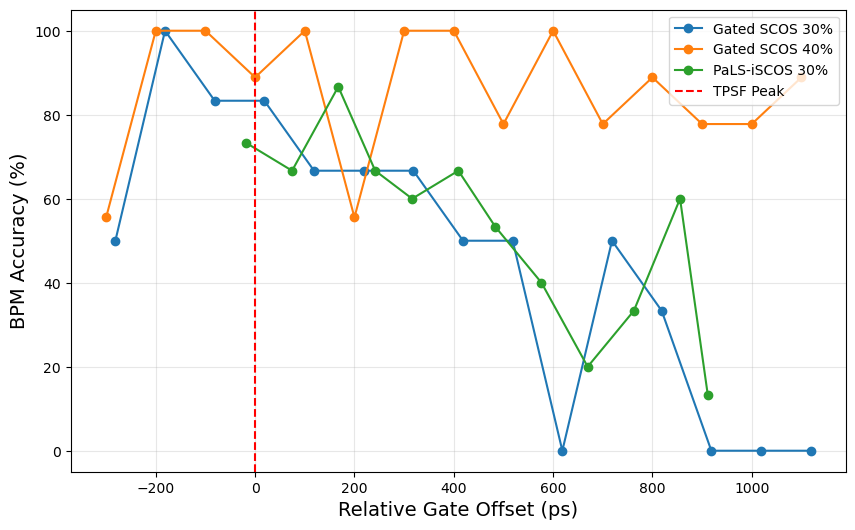

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_accuracy_vs_offset_from_60_to_100.png
BPM Accuracy vs Relative Offset – Power 30% (BPM between 60 and 100)


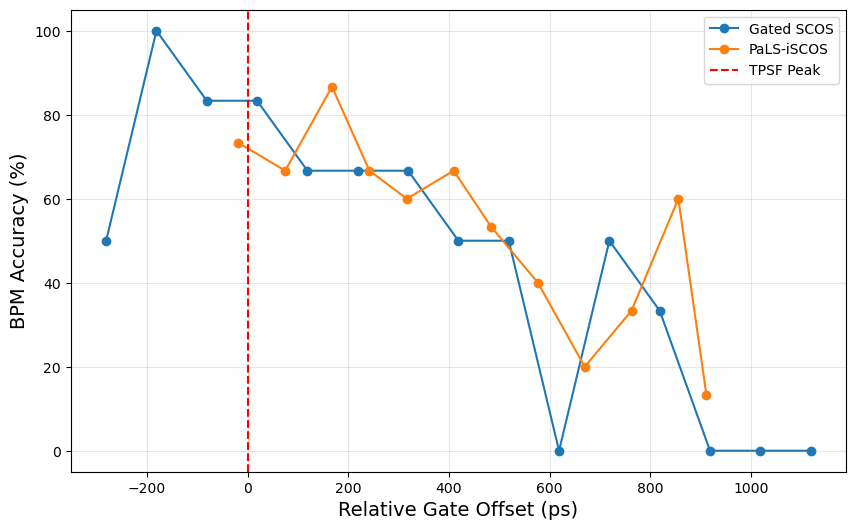

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_accuracy_vs_offset_30pct_from_60_to_100.png
BPM Accuracy vs Relative Offset – Power 40% (BPM between 60 and 100)


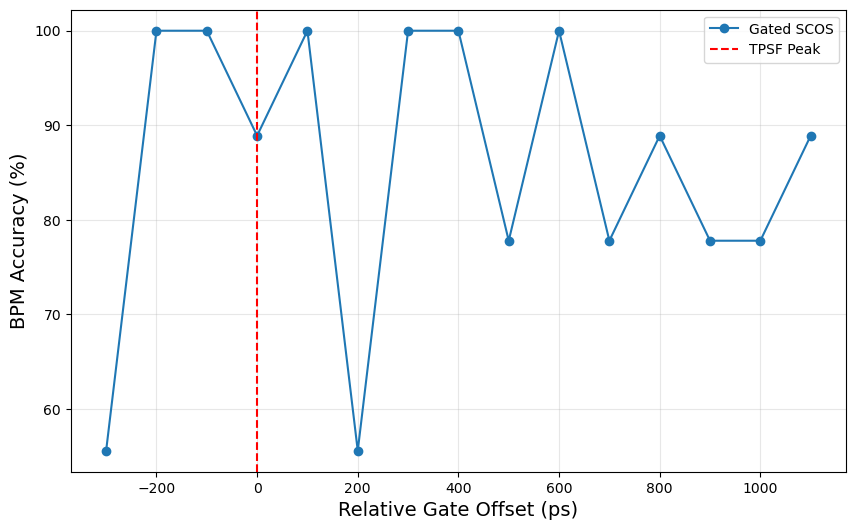

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_accuracy_vs_offset_40pct_from_60_to_100.png
BPM Mean and Std vs Relative Offset


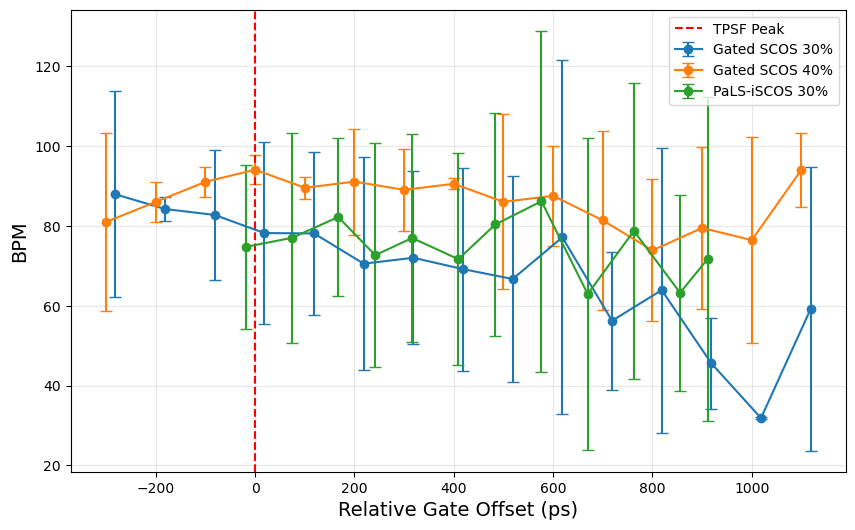

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_mean_std_vs_offset.png
BPM Mean and Std vs Relative Offset – Power 30%


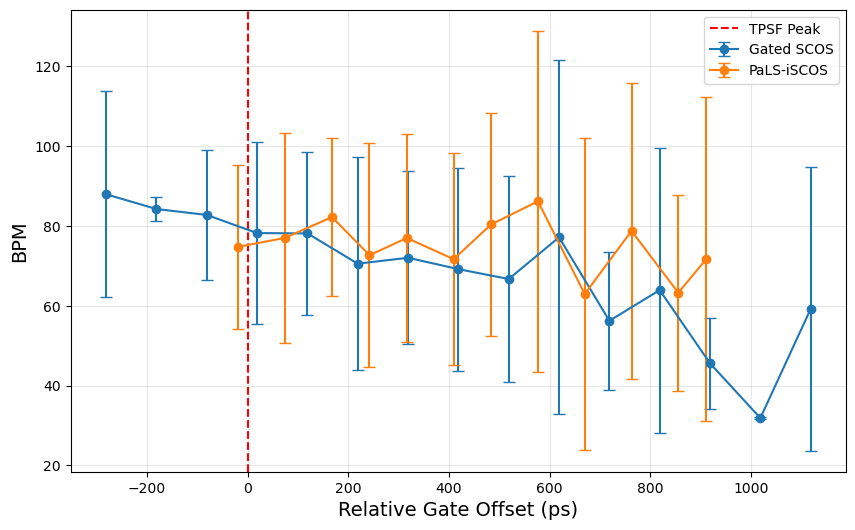

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_mean_std_vs_offset_30pct.png
BPM Mean and Std vs Relative Offset – Power 40%


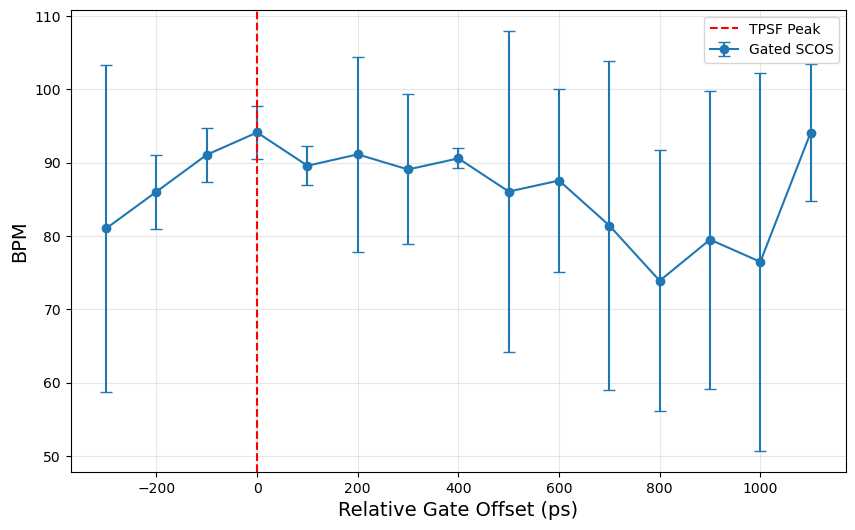

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_mean_std_vs_offset_40pct.png


In [16]:
# Count accurate and inaccurate BPM detections for each method, power, and relative offset

PBM_MIN=60
PBM_MAX=100
bpm_counts_true_offset = (
  df[df['BPM'].between(PBM_MIN, PBM_MAX)]
    .groupby(['method', 'power_level', 'relative_offset_ns'])['BPM']
    .count()
    .rename('Accurate_BPM_Count')
)
bpm_counts_false_offset = (
  df[~df['BPM'].between(PBM_MIN, PBM_MAX)]
    .groupby(['method', 'power_level', 'relative_offset_ns'])['BPM']
    .count()
    .rename('Inaccurate_BPM_Count')
)
bpm_accuracy_offset = pd.concat([bpm_counts_true_offset, bpm_counts_false_offset], axis=1).fillna(0).astype(int)
bpm_accuracy_offset['Total_Count'] = bpm_accuracy_offset.sum(axis=1)
bpm_accuracy_offset['Accuracy_%'] = (bpm_accuracy_offset['Accurate_BPM_Count'] / bpm_accuracy_offset['Total_Count'] * 100).round(2)

print(f'\nAccurate BPM Counts by Relative Offset ({PBM_MIN} < BPM < {PBM_MAX}):')
print(bpm_accuracy_offset.to_string())

fname = f'{SAVE_PATH}/bpm_accuracy_by_offset_from_{PBM_MIN}_to_{PBM_MAX}.csv'
bpm_accuracy_offset.to_csv(fname)
print(f'Saved → {fname}')
# order the index for plotting
bpm_accuracy_offset = bpm_accuracy_offset.sort_index(level=['method', 'power_level', 'relative_offset_ns'])



# Create a plot of BPM accuracy vs relative offset for each method and power level
fig, ax = plt.subplots(figsize=(10, 6))
for (method, power), group in bpm_accuracy_offset.groupby(level=[0, 1]):
    ax.plot(group.index.get_level_values('relative_offset_ns'), group['Accuracy_%'], marker='o', label=f'{method} {power}')
ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
print(f'BPM Accuracy vs Relative Offset (BPM between {PBM_MIN} and {PBM_MAX})')
ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
ax.set_ylabel('BPM Accuracy (%)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
fname = f'{SAVE_PATH}/bpm_accuracy_vs_offset_from_{PBM_MIN}_to_{PBM_MAX}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')
#One figure per power level
for power in POWER_LEVELS:
    sub_power = bpm_accuracy_offset.xs(power, level='power_level')
    if sub_power.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    for method, group in sub_power.groupby(level='method'):
        ax.plot(group.index.get_level_values('relative_offset_ns'), group['Accuracy_%'], marker='o', label=method)
    ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
    print(f'BPM Accuracy vs Relative Offset – Power {power} (BPM between {PBM_MIN} and {PBM_MAX})')
    ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
    ax.set_ylabel('BPM Accuracy (%)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')
    fname = f'{SAVE_PATH}/bpm_accuracy_vs_offset_{power.replace("%", "pct")}_from_{PBM_MIN}_to_{PBM_MAX}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')



# Create a plot of BPM mean and std vs relative offset for each method, power level
fig, ax = plt.subplots(figsize=(10, 6))
for (method, power), group in df.groupby(['method', 'power_level']):
    bpm_stats = group.groupby('relative_offset_ns')['BPM'].agg(['mean', 'std']).reset_index()
    ax.errorbar(bpm_stats['relative_offset_ns'], bpm_stats['mean'], yerr=bpm_stats['std'], marker='o', label=f'{method} {power}', capsize=4)
ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
print(f'BPM Mean and Std vs Relative Offset')
ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
ax.set_ylabel('BPM', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
fname = f'{SAVE_PATH}/bpm_mean_std_vs_offset.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')

#One figure per power level
for power in POWER_LEVELS:
    sub_power = df[df['power_level'] == power]
    if sub_power.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    for method, group in sub_power.groupby('method'):
        bpm_stats = group.groupby('relative_offset_ns')['BPM'].agg(['mean', 'std']).reset_index()
        ax.errorbar(bpm_stats['relative_offset_ns'], bpm_stats['mean'], yerr=bpm_stats['std'], marker='o', label=method, capsize=4)
    ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
    print(f'BPM Mean and Std vs Relative Offset – Power {power}')
    ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
    ax.set_ylabel('BPM', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')
    fname = f'{SAVE_PATH}/bpm_mean_std_vs_offset_{power.replace("%", "pct")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')


BPM Median and IQR vs Relative Offset


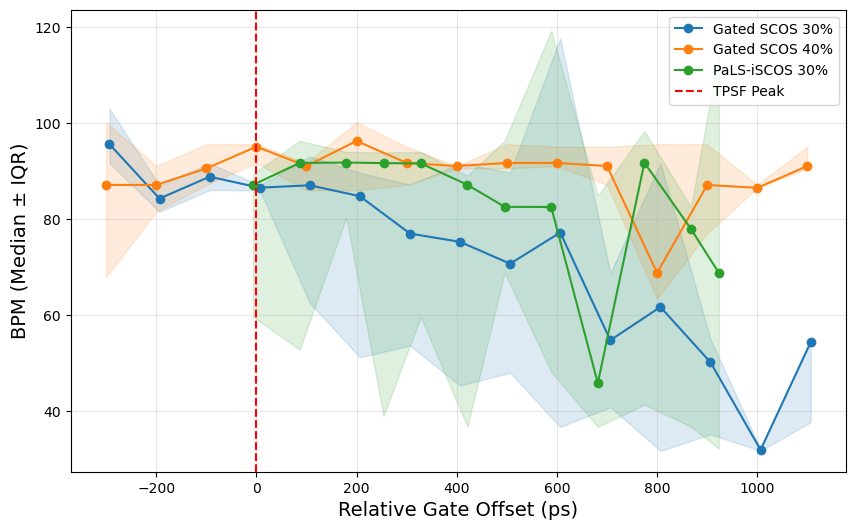

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_median_iqr_vs_offset.png
BPM Median and IQR vs Relative Offset – Power 30%


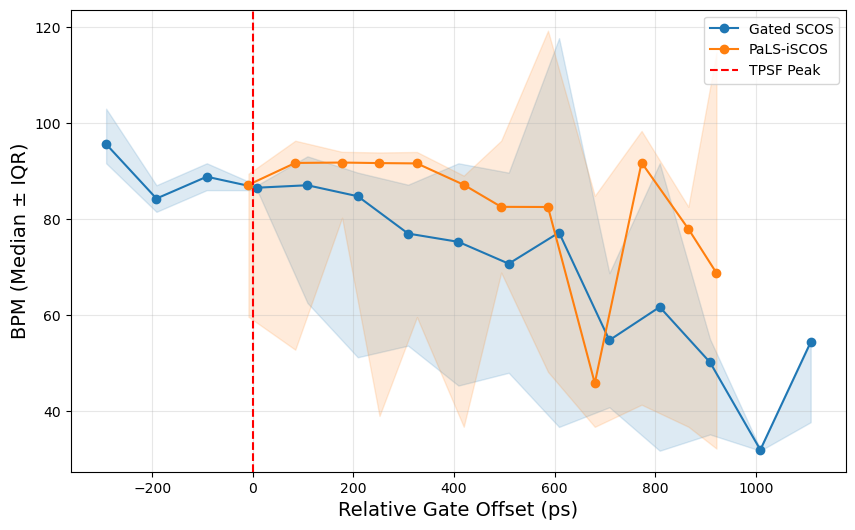

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_median_iqr_vs_offset_30pct.png
BPM Median and IQR vs Relative Offset – Power 40%


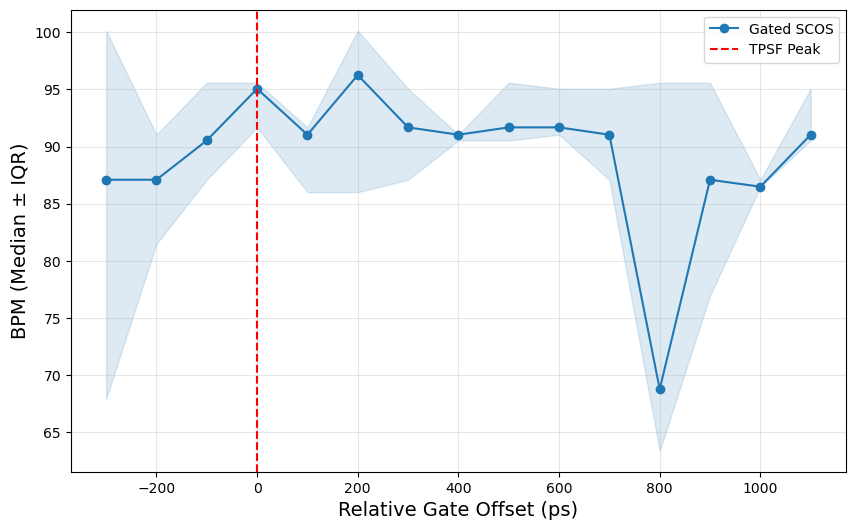

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_median_iqr_vs_offset_40pct.png
BPM Median Heatmap vs Relative Offset


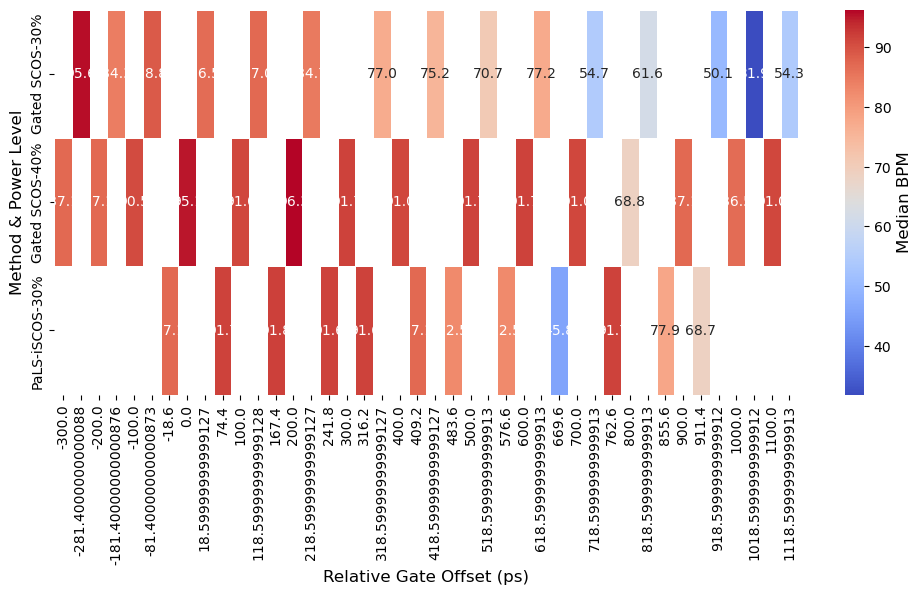

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_heatmap_vs_offset.png


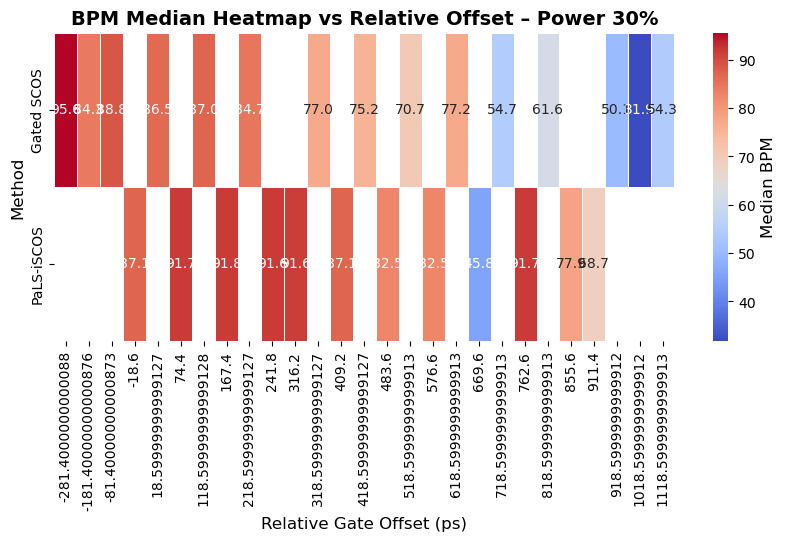

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_heatmap_vs_offset_30pct.png


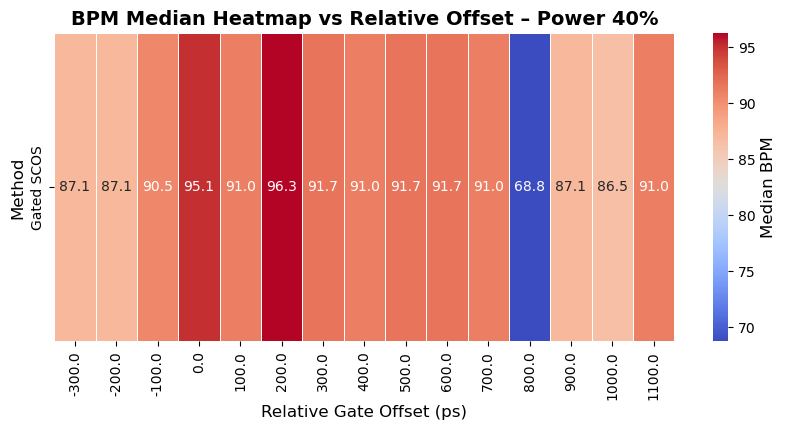

Saved → D:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\scos_analysis_results_plots/bpm_heatmap_vs_offset_40pct.png
BPM Estimation Instability (Lower is Better)


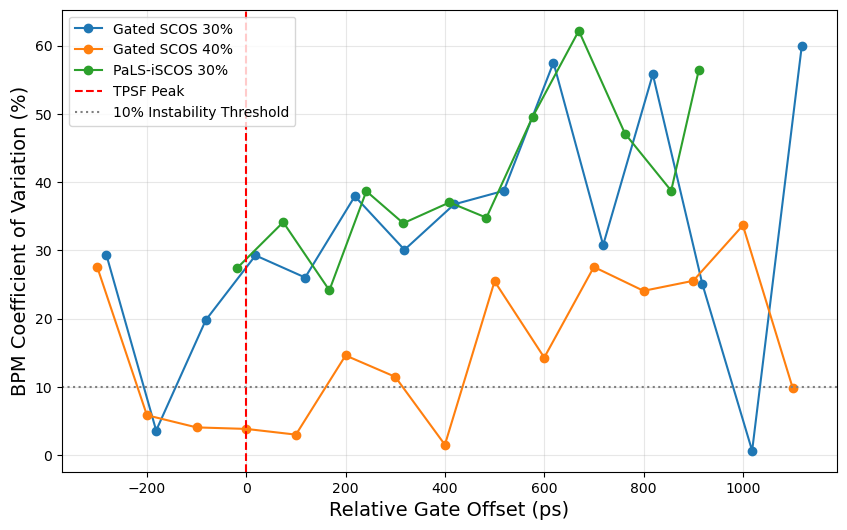

BPM Estimation Instability – Power 30% (Lower is Better)


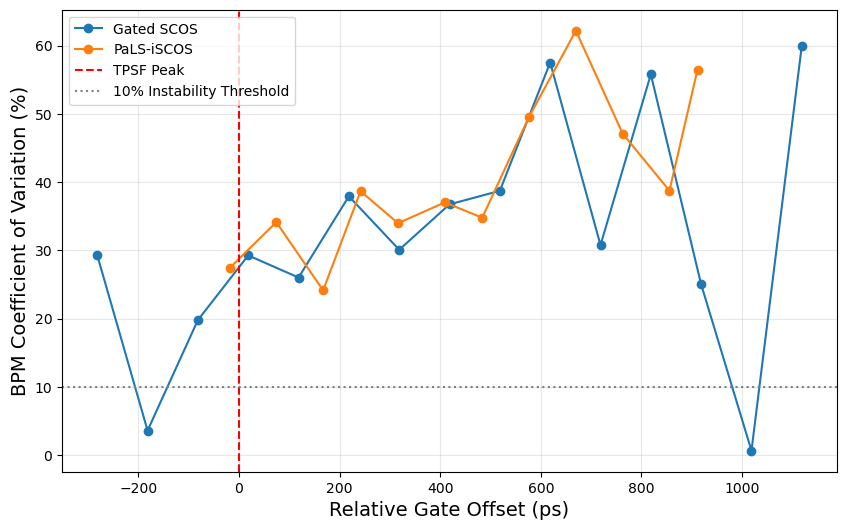

BPM Estimation Instability – Power 40% (Lower is Better)


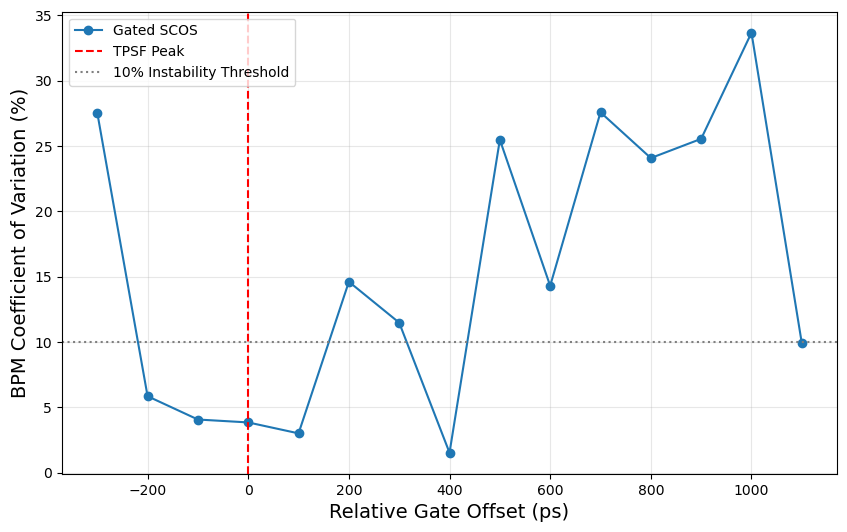

BPM Precision / Signal Quality (Higher is Better)


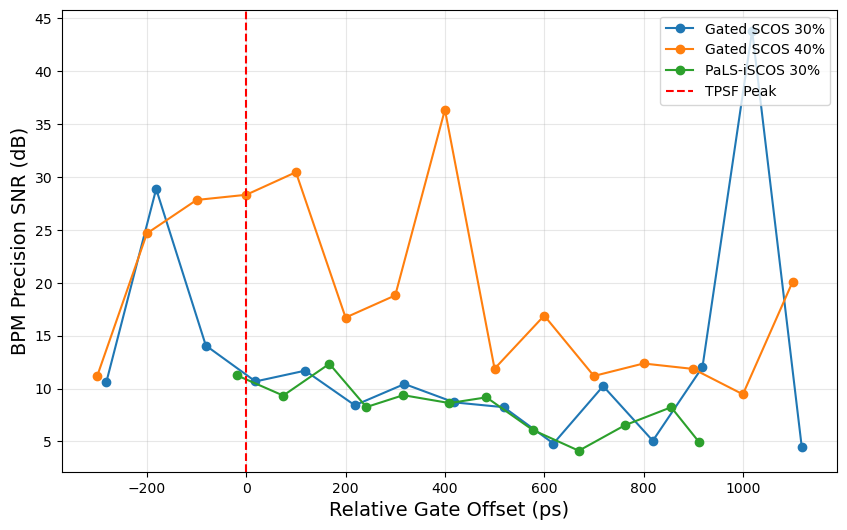

BPM Precision / Signal Quality – Power 30% (Higher is Better)


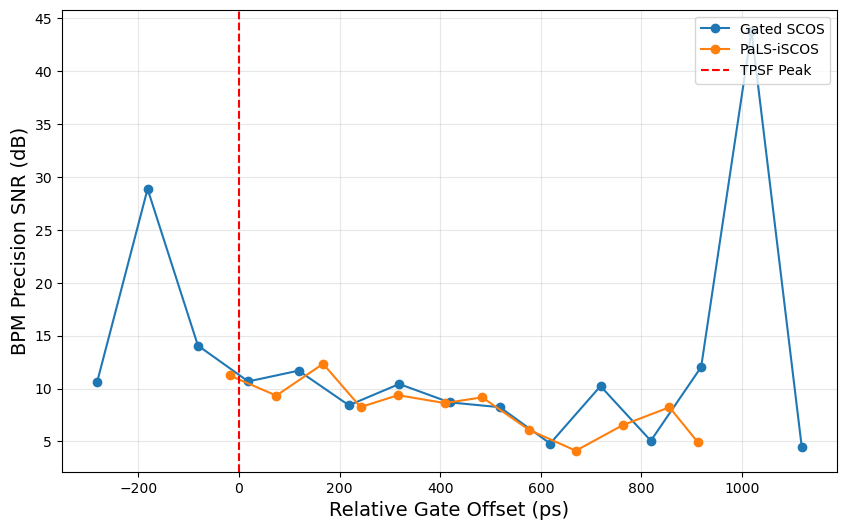

BPM Precision / Signal Quality – Power 40% (Higher is Better)


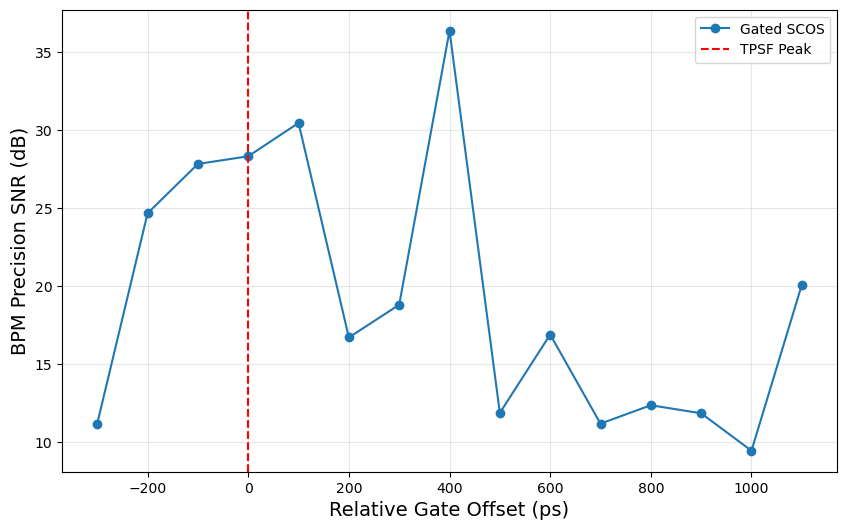

In [17]:
import numpy as np

# --- OPTION 1: COMBINED FIGURE (All Methods & Powers) ---
fig, ax = plt.subplots(figsize=(10, 6))

groups = list(df.groupby(['method', 'power_level']))
num_groups = len(groups)
# Calculate small horizontal shifts (e.g. within ±12 ps) to decouple overlapping points
jitter_offsets = np.linspace(-12, 12, num_groups) if num_groups > 1 else [0]

for idx, ((method, power), group) in enumerate(groups):
    bpm_stats = group.groupby('relative_offset_ns')['BPM'].agg(
        median='median',
        q25=lambda x: np.percentile(x, 25),
        q75=lambda x: np.percentile(x, 75)
    ).reset_index()
    
    # Apply horizontal jitter
    x_jittered = bpm_stats['relative_offset_ns'] + jitter_offsets[idx]
    
    line, = ax.plot(x_jittered, bpm_stats['median'], marker='o', label=f'{method} {power}')
    ax.fill_between(x_jittered, bpm_stats['q25'], bpm_stats['q75'], color=line.get_color(), alpha=0.15)

ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
print('BPM Median and IQR vs Relative Offset')
ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
ax.set_ylabel('BPM (Median ± IQR)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
fname = f'{SAVE_PATH}/bpm_median_iqr_vs_offset.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')

# --- OPTION 1: ONE FIGURE PER POWER LEVEL ---
for power in POWER_LEVELS:
    sub_power = df[df['power_level'] == power]
    if sub_power.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    sub_groups = list(sub_power.groupby('method'))
    num_sub = len(sub_groups)
    method_jitters = np.linspace(-10, 10, num_sub) if num_sub > 1 else [0]

    for idx, (method, group) in enumerate(sub_groups):
        bpm_stats = group.groupby('relative_offset_ns')['BPM'].agg(
            median='median',
            q25=lambda x: np.percentile(x, 25),
            q75=lambda x: np.percentile(x, 75)
        ).reset_index()
        
        x_jittered = bpm_stats['relative_offset_ns'] + method_jitters[idx]

        line, = ax.plot(x_jittered, bpm_stats['median'], marker='o', label=method)
        ax.fill_between(x_jittered, bpm_stats['q25'], bpm_stats['q75'], color=line.get_color(), alpha=0.15)

    ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
    print(f'BPM Median and IQR vs Relative Offset – Power {power}')
    ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
    ax.set_ylabel('BPM (Median ± IQR)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')
    fname = f'{SAVE_PATH}/bpm_median_iqr_vs_offset_{power.replace("%", "pct")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')
    
    
    import seaborn as sns

# --- OPTION 2: COMBINED HEATMAP (All Methods & Powers) ---
pivot_combined = df.pivot_table(
    index=['method', 'power_level'],
    columns='relative_offset_ns',
    values='BPM',
    aggfunc='median'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot_combined, 
    annot=True, 
    fmt=".1f", 
    cmap="coolwarm", 
    cbar_kws={'label': 'Median BPM'}, 
    ax=ax,
    linewidths=0.5
)
print('BPM Median Heatmap vs Relative Offset')
ax.set_xlabel('Relative Gate Offset (ps)', fontsize=12)
ax.set_ylabel('Method & Power Level', fontsize=12)
fname = f'{SAVE_PATH}/bpm_heatmap_vs_offset.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')

# --- OPTION 2: ONE HEATMAP PER POWER LEVEL ---
for power in POWER_LEVELS:
    sub_power = df[df['power_level'] == power]
    if sub_power.empty:
        continue

    pivot_power = sub_power.pivot_table(
        index='method',
        columns='relative_offset_ns',
        values='BPM',
        aggfunc='median'
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        pivot_power, 
        annot=True, 
        fmt=".1f", 
        cmap="coolwarm", 
        cbar_kws={'label': 'Median BPM'}, 
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(f'BPM Median Heatmap vs Relative Offset – Power {power}', fontsize=14)
    ax.set_xlabel('Relative Gate Offset (ps)', fontsize=12)
    ax.set_ylabel('Method', fontsize=12)
    fname = f'{SAVE_PATH}/bpm_heatmap_vs_offset_{power.replace("%", "pct")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')
    
    import numpy as np
import matplotlib.pyplot as plt

# --- 1. COEFFICIENT OF VARIATION (CV %) PLOT ---
fig, ax = plt.subplots(figsize=(10, 6))

for (method, power), group in df.groupby(['method', 'power_level']):
    # Calculate Mean, Std, and CV (%)
    stats = group.groupby('relative_offset_ns')['BPM'].agg(['mean', 'std']).reset_index()
    stats['CV'] = (stats['std'] / stats['mean']) * 100.0

    ax.plot(stats['relative_offset_ns'], stats['CV'], marker='o', label=f'{method} {power}')

ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
ax.axhline(10, color='gray', linestyle=':', label='10% Instability Threshold') # Optional threshold line
ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
ax.set_ylabel('BPM Coefficient of Variation (%)', fontsize=14)
print('BPM Estimation Instability (Lower is Better)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper left')

fname = f'{SAVE_PATH}/bpm_cv_vs_offset.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()

for power in POWER_LEVELS:
    sub_power = df[df['power_level'] == power]
    if sub_power.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    for method, group in sub_power.groupby('method'):
        stats = group.groupby('relative_offset_ns')['BPM'].agg(['mean', 'std']).reset_index()
        stats['CV'] = (stats['std'] / stats['mean']) * 100.0
        ax.plot(stats['relative_offset_ns'], stats['CV'], marker='o', label=method)

    ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
    ax.axhline(10, color='gray', linestyle=':', label='10% Instability Threshold') # Optional threshold line
    ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
    ax.set_ylabel('BPM Coefficient of Variation (%)', fontsize=14)
    print(f'BPM Estimation Instability – Power {power} (Lower is Better)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper left')

    fname = f'{SAVE_PATH}/bpm_cv_vs_offset_{power.replace("%", "pct")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


# --- 2. BPM SNR (dB) PLOT ---
fig, ax = plt.subplots(figsize=(10, 6))

for (method, power), group in df.groupby(['method', 'power_level']):
    stats = group.groupby('relative_offset_ns')['BPM'].agg(['mean', 'std']).reset_index()
    # Avoid division by zero
    stats['std'] = stats['std'].replace(0, 1e-6)
    stats['SNR_dB'] = 20 * np.log10(stats['mean'] / stats['std'])

    ax.plot(stats['relative_offset_ns'], stats['SNR_dB'], marker='o', label=f'{method} {power}')

ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
ax.set_ylabel('BPM Precision SNR (dB)', fontsize=14)
print('BPM Precision / Signal Quality (Higher is Better)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')

fname = f'{SAVE_PATH}/bpm_snr_vs_offset.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()

for power in POWER_LEVELS:
    sub_power = df[df['power_level'] == power]
    if sub_power.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    for method, group in sub_power.groupby('method'):
        stats = group.groupby('relative_offset_ns')['BPM'].agg(['mean', 'std']).reset_index()
        stats['std'] = stats['std'].replace(0, 1e-6)
        stats['SNR_dB'] = 20 * np.log10(stats['mean'] / stats['std'])
        ax.plot(stats['relative_offset_ns'], stats['SNR_dB'], marker='o', label=method)

    ax.axvline(0, color='red', linestyle='--', label='TPSF Peak')
    ax.set_xlabel('Relative Gate Offset (ps)', fontsize=14)
    ax.set_ylabel('BPM Precision SNR (dB)', fontsize=14)
    print(f'BPM Precision / Signal Quality – Power {power} (Higher is Better)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')

    fname = f'{SAVE_PATH}/bpm_snr_vs_offset_{power.replace("%", "pct")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

## Sensitivity Summary by Method

This section plots the sensitivity metric versus the gate offset relative to the TPSF peak.

- **Gated** rows use `time_gate_ps`
- **ISCOS** and **PaLS-iSCOS** rows use `coherence_gate_ps`


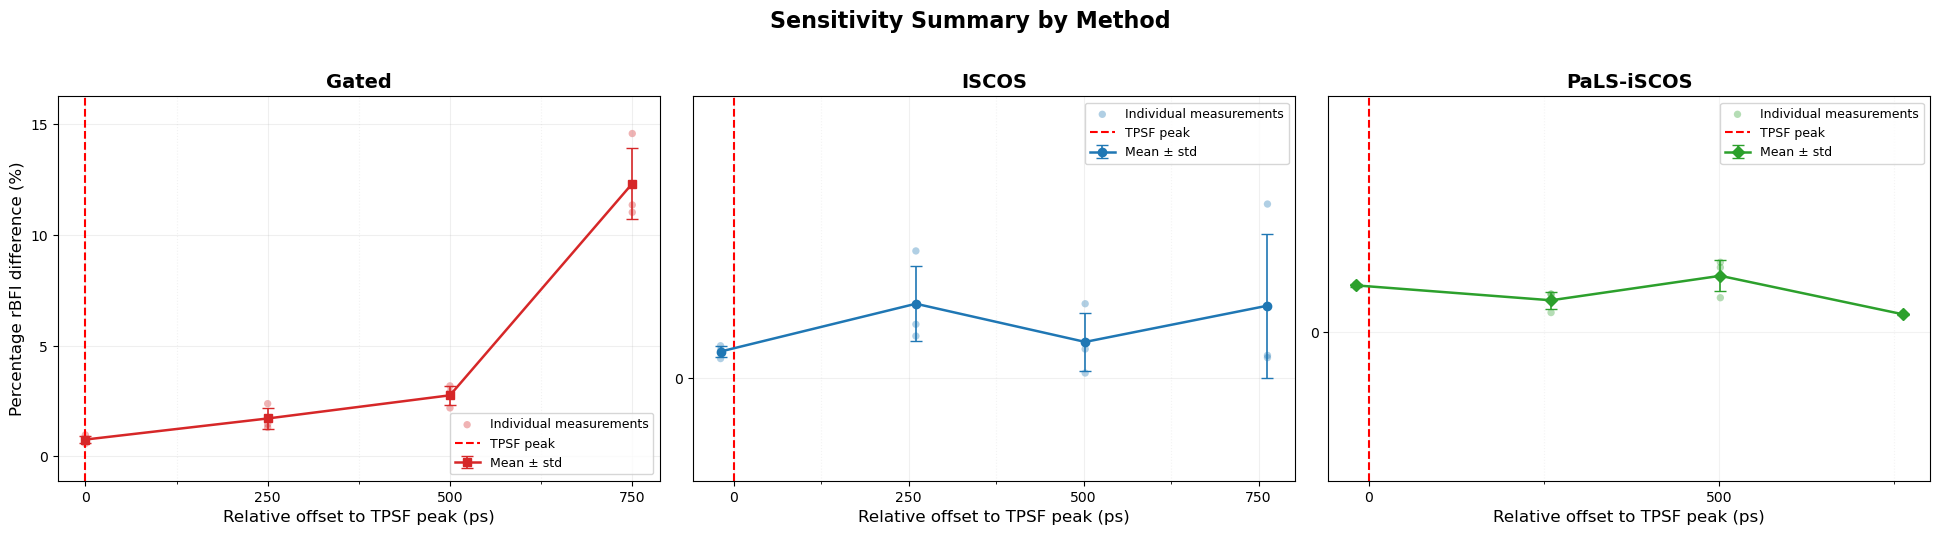

Saved → D:\Shira_TZ_ISCOS\20-05-2026  1cm Gated+ ISCOS Sensetivity Tests Shira\sensitivity_test_results_plots\sensitivity_summary_by_method.png


In [18]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# SENSITIVITY_CSV = r'C:\Users\Shira\מעבדה\ISCOS\Measurement\14-05-2026 Gated+ISCOS Sensetivity Test\sensitivity_test_results.csv'
SENSITIVITY_CSV = r'D:\Shira_TZ_ISCOS\20-05-2026  1cm Gated+ ISCOS Sensetivity Tests Shira\sensitivity_test_results.csv'  # <-- adjust if needed
SENSITIVITY_SAVE = SENSITIVITY_CSV.replace('.csv', '_plots')
Path(SENSITIVITY_SAVE).mkdir(parents=True, exist_ok=True)

sens_df = pd.read_csv(SENSITIVITY_CSV)


def method_offset(row):
    method = str(row.get('method', ''))
    if 'Gated' in method:
        return row.get('time_gate_ps')
    return row.get('coherence_gate_ps')


sens_df['offset_ps'] = sens_df.apply(method_offset, axis=1)
sens_df = sens_df.dropna(subset=['offset_ps', 'percentage_rBFI_difference', 'method'])
sens_df['offset_ps'] = sens_df['offset_ps'].astype(float)

# Keep the table on the full dataset, but remove the lone PaLS-iSCOS negative outlier from the plot
plot_df = sens_df[~((sens_df['method'] == 'PaLS-iSCOS') & (sens_df['offset_ps'] < -1000))].copy()

# prefer the summary CSV if the analysis script created it
summary_csv_candidates = [
    Path(SENSITIVITY_CSV).parent / 'sensitivity_test_results_summary.csv',
    Path(SENSITIVITY_CSV).with_name('sensitivity_test_results_summary.csv')
]
summary = None
for sc in summary_csv_candidates:
    if sc.exists():
        try:
            summary = pd.read_csv(sc)
            # expected folder-level columns from the analyzer
            if set(['method', 'offset_ps', 'percentage_mean', 'percentage_std']).issubset(summary.columns):
                break
            else:
                summary = None
        except Exception:
            summary = None

if summary is None:
    # fallback: compute folder-level summary from sens_df (treat each folder as one sample)
    summary = (
        sens_df.groupby(['method', 'offset_ps'])['percentage_rBFI_difference']
        .agg(mean='mean', std='std', n='count')
        .reset_index()
        .rename(columns={'mean': 'percentage_mean', 'std': 'percentage_std'})
        .sort_values('offset_ps')
    )
else:
    # ensure correct dtypes
    summary['offset_ps'] = pd.to_numeric(summary['offset_ps'], errors='coerce')

# method ordering
method_order = [name for name in ['Gated', 'ISCOS', 'PaLS-iSCOS'] if name in sens_df['method'].unique()]
if not method_order:
    method_order = sorted(sens_df['method'].unique())

fig, axes = plt.subplots(1, len(method_order), figsize=(6.5 * len(method_order), 5.2), sharey=False)
if len(method_order) == 1:
    axes = [axes]

method_styles = {
    'Gated': {'color': '#d62728', 'marker': 's', 'x_major': 250, 'x_minor': 125, 'y_major': 5, 'grid_alpha': 0.20},
    'ISCOS': {'color': '#1f77b4', 'marker': 'o', 'x_major': 250, 'x_minor': 125, 'y_major': 5, 'grid_alpha': 0.18},
    'PaLS-iSCOS': {'color': '#2ca02c', 'marker': 'D', 'x_major': 500, 'x_minor': 250, 'y_major': 5, 'grid_alpha': 0.16},
}

for ax, method in zip(axes, method_order):
    method_summary = summary[summary['method'] == method]
    if method_summary.empty:
        ax.set_axis_off()
        continue

    style = method_styles.get(method, {'color': '#444444', 'marker': 'o', 'x_major': 250, 'x_minor': 125, 'y_major': 5, 'grid_alpha': 0.18})

    # compute y-range from plotted points and summary; handle missing individual points
    individual_vals = plot_df.loc[plot_df['method'] == method, 'percentage_rBFI_difference']
    summary_vals = method_summary['percentage_mean']
    y_min_candidates = [v for v in [individual_vals.min() if not individual_vals.empty else None,
                                   summary_vals.min() if not summary_vals.empty else None] if v is not None]
    y_max_candidates = [v for v in [individual_vals.max() if not individual_vals.empty else None,
                                   summary_vals.max() if not summary_vals.empty else None] if v is not None]
    if not y_min_candidates or not y_max_candidates:
        ax.set_axis_off(); continue
    y_min = min(y_min_candidates)
    y_max = max(y_max_candidates)
    y_pad = max(1.0, 0.12 * max(1.0, y_max - y_min))

    ax.errorbar(
        method_summary['offset_ps'],
        method_summary['percentage_mean'],
        yerr=method_summary['percentage_std'].fillna(0),
        fmt=f'-{style["marker"]}',
        linewidth=1.8,
        markersize=6,
        capsize=4,
        color=style['color'],
        ecolor=style['color'],
        elinewidth=1.2,
        label='Mean ± std',
    )

    ax.scatter(
        plot_df.loc[plot_df['method'] == method, 'offset_ps'],
        plot_df.loc[plot_df['method'] == method, 'percentage_rBFI_difference'],
        s=28,
        color=style['color'],
        alpha=0.35,
        edgecolors='none',
        label='Individual measurements',
    )

    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='TPSF peak')
    ax.set_title(method, fontsize=14, fontweight='bold')
    ax.set_xlabel('Relative offset to TPSF peak (ps)')
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.xaxis.set_major_locator(MultipleLocator(style['x_major']))
    ax.xaxis.set_minor_locator(MultipleLocator(style['x_minor']))
    ax.yaxis.set_major_locator(MultipleLocator(style['y_major']))
    ax.grid(True, which='major', axis='both', alpha=style['grid_alpha'], linestyle='-')
    ax.grid(True, which='minor', axis='x', alpha=style['grid_alpha'] * 0.8, linestyle=':')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Percentage rBFI difference (%)')
fig.suptitle('Sensitivity Summary by Method', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
out_file = Path(SENSITIVITY_SAVE) / 'sensitivity_summary_by_method.png'
plt.savefig(out_file, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_file}')
